<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/17_batch_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Batch Normalization

As neural networks become deeper, the distribution of activations changes during training. This makes optimization slower and less stable.

Batch Normalization normalizes the output of a layer before passing it to the next layer.

It helps the network train faster, improves stability, and often leads to better model performance.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
X = np.array([
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1],
    [0,0],[0,1],[1,0],[1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
model_without_bn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_without_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history_without = model_without_bn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=0
)

In [6]:
model_with_bn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(16),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_with_bn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history_with = model_with_bn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=0
)

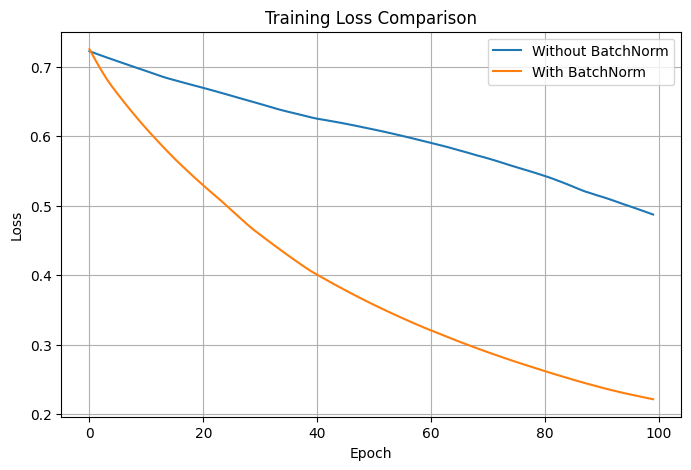

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["loss"], label="Without BatchNorm")
plt.plot(history_with.history["loss"], label="With BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid()

plt.show()

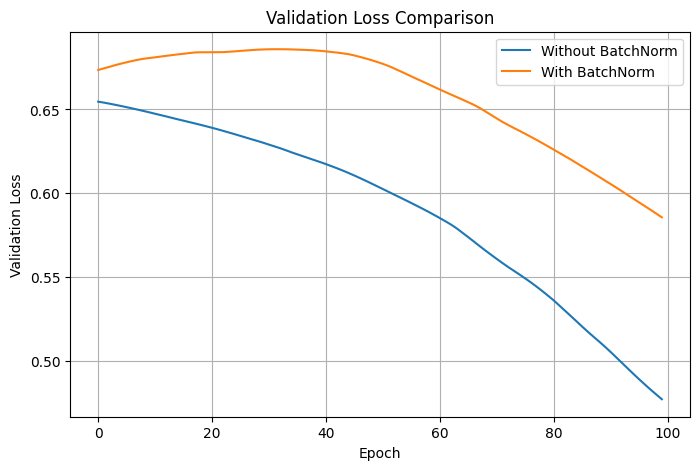

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["val_loss"], label="Without BatchNorm")
plt.plot(history_with.history["val_loss"], label="With BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")

plt.legend()
plt.grid()

plt.show()

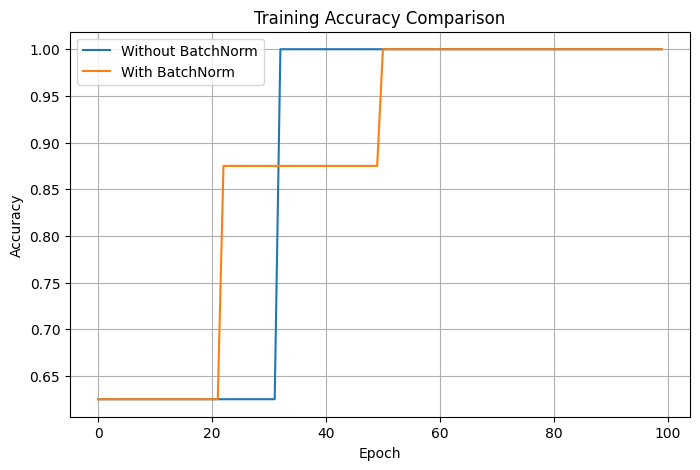

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["accuracy"], label="Without BatchNorm")
plt.plot(history_with.history["accuracy"], label="With BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.grid()

plt.show()

In [11]:
comparison = pd.DataFrame({
    "Without Batch Normalization":[
        "Slower Training",
        "Less Stable",
        "More Sensitive to Learning Rate"
    ],
    "With Batch Normalization":[
        "Faster Training",
        "More Stable",
        "Allows Higher Learning Rates"
    ]
})

comparison

,Without Batch Normalization,With Batch Normalization
0,Slower Training,Faster Training
1,Less Stable,More Stable
2,More Sensitive to Learning Rate,Allows Higher Learning Rates


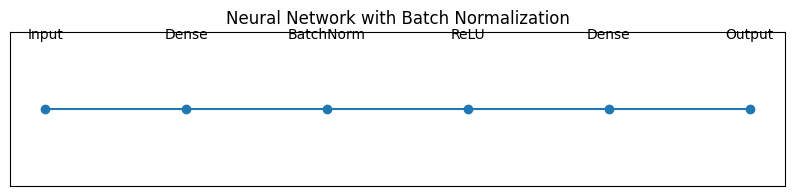

In [12]:
steps = [
    "Input",
    "Dense",
    "BatchNorm",
    "ReLU",
    "Dense",
    "Output"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Neural Network with Batch Normalization")

plt.show()